**Part 1 — Load and Explore the Text Data**
This project is unsupervised Machine learning for text dataset

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Load the 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

# Text documents
documents = newsgroups.data

# Actual topic labels - do NOT use for K-Means training
y = newsgroups.target

Since this is a text dataset, removing the headers, footers and quotes(metadata) is useful because they could cause the clustering to focus on metadata rather than the actual content of the posts.

In [2]:
#check the number of documents
print("Number of documents:", len(documents))

Number of documents: 18846


Inspect the first few documents

In [3]:
print(documents[0])



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




In [4]:
print(documents[2])





	Finally you said what you dream about. Mediterranean???? That was new....
	The area will be "greater" after some years, like your "holocaust" numbers......




		*****
	Is't July in USA now????? Here in Sweden it's April and still cold.
	Or have you changed your calendar???


						    ****************
						    ******************
			    ***************


	NOTHING OF THE MENTIONED IS TRUE, BUT LET SAY IT's TRUE.
	
	SHALL THE AZERI WOMEN AND CHILDREN GOING TO PAY THE PRICE WITH
						    **************
	BEING RAPED, KILLED AND TORTURED BY THE ARMENIANS??????????
	
	HAVE YOU HEARDED SOMETHING CALLED: "GENEVA CONVENTION"???????
	YOU FACIST!!!!!



	Ohhh i forgot, this is how Armenians fight, nobody has forgot
	you killings, rapings and torture against the Kurds and Turks once
	upon a time!
      
       


Ohhhh so swedish RedCross workers do lie they too? What ever you say
"regional killer", if you don't like the person then shoot him that's your policy.....l


										i
									

In [5]:
#Check the number of categories
print("Number of categories:", len(newsgroups.target_names))

Number of categories: 20


In [7]:
#Display the category names
for i, category in enumerate(newsgroups.target_names):
    print(i, category)

0 alt.atheism
1 comp.graphics
2 comp.os.ms-windows.misc
3 comp.sys.ibm.pc.hardware
4 comp.sys.mac.hardware
5 comp.windows.x
6 misc.forsale
7 rec.autos
8 rec.motorcycles
9 rec.sport.baseball
10 rec.sport.hockey
11 sci.crypt
12 sci.electronics
13 sci.med
14 sci.space
15 soc.religion.christian
16 talk.politics.guns
17 talk.politics.mideast
18 talk.politics.misc
19 talk.religion.misc


Display some few example of document(example document 0 and 2 have different number of characters. therefore due to un even leangth. i will display the first 500 characters


In [8]:
for i in range(5):
    print(f"\n--- Document {i + 1} ---")
    print(documents[i][:500])


--- Document 1 ---


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a

--- Document 2 ---
My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond Stealth Pro Local Bus

  - Orchid Farenheit 1280

  - ATI Graphics Ultra Pro

  - Any other high-performance VLB card


Please post or email.  Thank you!

  - Matt


--- Document 3 ---




	Finally you said what you dream about. Mediterranean???? That was new....
	The area will be "greater" after s

We cannot give the original text directly to K-Means because K-Means works with numerical values and calculates distances between observations (centriods). Text consists of words and characters rather than numbers. Therefore, the documents must first be converted into numerical features using a method such as TF-IDF.

**Part 2 — Convert Text into Numbers**

In [9]:
# converting text to numbers
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000 #this keeps the number of clustering manageable
)

X_tfidf = tfidf.fit_transform(documents)

#verify the resuting shapes
print("TF-IDF shape:", X_tfidf.shape)
print("Number of documents:", X_tfidf.shape[0])
print("Number of features:", X_tfidf.shape[1])

TF-IDF shape: (18846, 5000)
Number of documents: 18846
Number of features: 5000


TF-IDF converts the text documents into numerical features based on the importance of words. Words that help distinguish one document from others receive greater importance, while very common words receive less importance.

**Part 3 — Group the Documents**

In [10]:
#when K = 5

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_tfidf)

In [11]:
print(clusters[:20])

[2 3 4 3 3 1 1 2 2 1 1 1 4 1 1 1 3 1 4 4]


Eachof teh document have been converted to numerical values. example, document 1 = cluster 2

In [12]:
# how many documents are in each cluster
import numpy as np

unique_clusters, counts = np.unique(
    clusters,
    return_counts=True
)

for cluster, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster}: {count} documents")

Cluster 0: 745 documents
Cluster 1: 9661 documents
Cluster 2: 1174 documents
Cluster 3: 3555 documents
Cluster 4: 3711 documents


Note that each cluster have different number of documents in the. K_mean clustering does not however requires that each cluster should have thesame number of documents. therefore, no standardization is needed.

**Part 4 — Understand the Clusters**

In [13]:
#Find several common words. in each cluster
feature_names = tfidf.get_feature_names_out()

In [14]:
# Sort the words in each cluster by their importance
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# Display the top 10 words for each cluster
for cluster in range(5):
    print(f"\nCluster {cluster}:")
    
    top_words = [
        feature_names[i]
        for i in order_centroids[cluster, :10]
    ]
    
    print(", ".join(top_words))


Cluster 0:
god, jesus, christ, believe, bible, faith, christian, christians, sin, people

Cluster 1:
just, like, edu, new, good, car, know, time, does, don

Cluster 2:
game, team, games, year, hockey, players, season, baseball, play, think

Cluster 3:
thanks, windows, drive, card, know, does, file, use, dos, program

Cluster 4:
people, don, think, just, government, like, know, right, say, time


Do the documents within each cluster appear to discuss similar topics?

No! not all the documents in each cluster have thesame  topic. example. cluster 0  and 2 has thesame topic which clould be "christain faith" and "Sport" respectively.But cluster 1, 3 and 4 are not easy to tell what the they are talking about.

In [15]:
# Display 3 documents from each cluster to confirm that they are common topics
for cluster in range(5):
    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster}")
    print("=" * 70)

    # Find documents belonging to this cluster
    cluster_indices = np.where(clusters == cluster)[0]

    # Display the first 3
    for index in cluster_indices[:3]:
        print("\nDocument:")
        print(documents[index][:500])
        print("-" * 70)


CLUSTER 0

Document:
Let the word of Christ dwell in you richly as you teach and admonish one
another with all wisdom, and as you sing psalms, hymns and spiritual songs with
gratitude in your hearts to God. 
Colossians 3:16

A reminder: These verses are from the New International Version. As with any
translation, faithfulness to the original Hebrew and Greek may vary from time
to time. If a verse sounds a little off occasionally, compare it with another
translation or with the original texts, if you are able to do s
----------------------------------------------------------------------

Document:

Actually, an apostle is someone who is sent.  If you will, mailmen could
be called apostles in that sense.  However, with Jesus, they were
designated and were given power.  Remember that there were many
thousands of people who witnessed what Jesus did.  That didn't make them
apostles, though.
----------------------------------------------------------------------

Document:
For the Lord Himse

**Part 5 — Visualize the Clusters**

In [20]:
# Convert sparse TF-IDF matrix to dense format
from sklearn.decomposition import PCA

X_dense = X_tfidf.toarray()

# Reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

print("Original shape:", X_tfidf.shape)
print("PCA shape:", X_pca.shape)

Original shape: (18846, 5000)
PCA shape: (18846, 2)


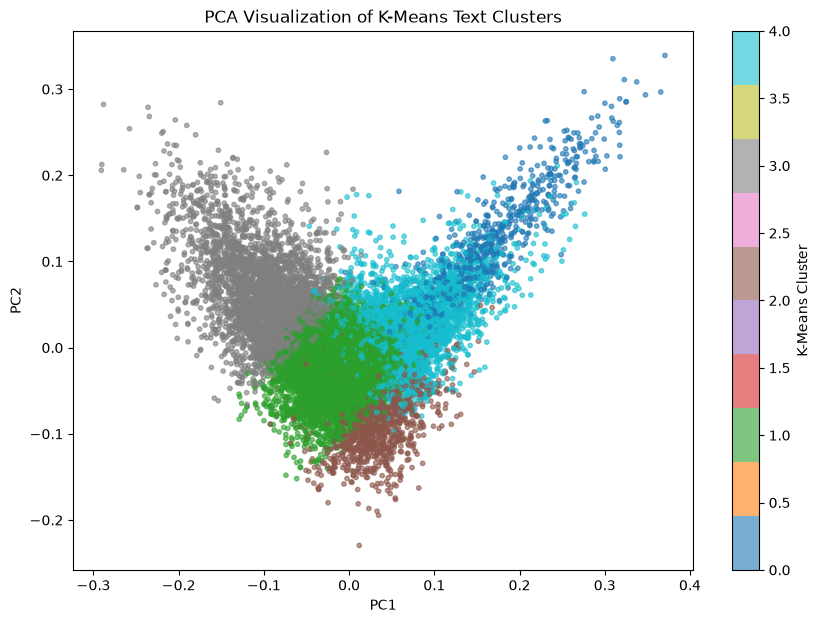

In [21]:
#Create Scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of K-Means Text Clusters")

plt.colorbar(scatter, label="K-Means Cluster")

plt.show()

Are some clusters clearly separated? Yes, most of the clusters are clearly separated such as the grey separated towards the upper let.

Are some clusters overlapping? yes the green, blue, teal and brown are overlapping in the centre

What does this tell you about grouping text documents?:
The visualization shows that K-Means can identify some meaningful structure/patterns in text documents, but the topics are not perfectly separated. Therefore, documents from different topics may use similar words, while documents within the same topic may use different vocabulary whcih then causes teh overpalling.

**Final Analysis**
What is TF-IDF and why is it useful for text data?. IT converts text into numerical features that machine-learning algorithms can process. It gives greater importance to words that are useful for distinguishing documents and less importance to words that appear frequently across many documents. This helps K-Means compare documents based on their word patterns.

What value of K did you use?
I used K = 5, meaning K-Means grouped the 18,846 documents into five clusters. A smaller number of clusters was used to keep the analysis manageable, even though the original dataset contains 20 newsgroup categories. That is the clusters represented broader themes from the 20 Newsgroups dataset

What topics did you find in the clusters?
The topics were identified by examining the most important TF-IDF words and sample documents within each cluster.

Did the documents within each cluster appear similar?
Yes, some documents within the same cluster appeared to discuss similar or related subjects while others did not

Were some clusters difficult to interpret?
Yes. Some clusters were more difficult to interpret because they contained documents unrelated topics.

What did the PCA visualization show? 
The PCA visualization showed that some clusters formed relatively distinct regions, However, some were considerable overlap, especially near the centre of the plot.

What is one limitation of using K-Means for text?
One limitation is that K-Means groups documents based on numerical similarity rather than understanding the actual meaning of the text. Documents from different topics can share similar words, causing them to be placed in the same cluster while documents about the same topic may use different vocabulary and be separated.